In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import cm
from numpy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D
import helpers as stoOpinf

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
power_labels = {
    "0p04": list("abefghi"),
    "0p07": list("abcdfghij"),
    "0p08": list("aefhij"),
    "0p10": list("bcdefhijk"),  # or "bcdefhijklmnopq"
    "0p15": list("abcdefghij"),
    "0p18": list("abcdefghij"),
    "0p20": list("abcdefghijklmn"),
    "0p25": list("abcdefghij"),
    "0p30": list("abcdefghijklmn"),
    "0p35": list("abcdefghijklmnop"),
}

power = "0p10"

Q, t, x, nx = stoOpinf.load_Q_dataset(power, power_labels[power])

In [4]:
Q_split, Qstate_all, X_mean, tt = stoOpinf.preprocess_Q(Q, t, labels = power_labels[power])

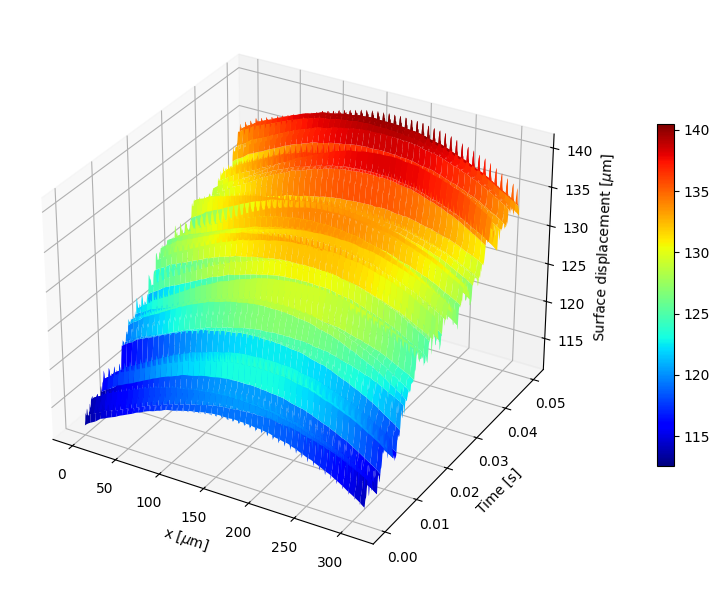

In [5]:
T, X = np.meshgrid(tt, x)
Z = Qstate_all.mean(axis=1)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, T, Z, cmap='jet', edgecolor='none'
)

ax.set_xlabel('x [$\\mu$m]')
ax.set_ylabel('Time [s]')
ax.set_zlabel('Surface displacement [$\\mu$m]')

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()


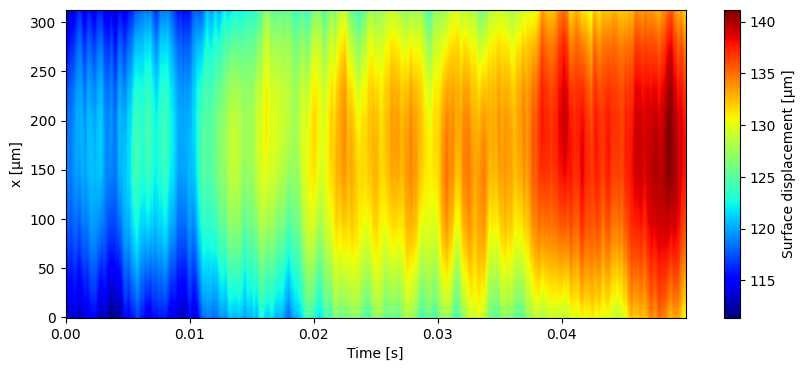

In [6]:
T, X = np.meshgrid(tt, x)

plt.figure(figsize=(10,4))
plt.pcolormesh(T, X, Qstate_all.mean(axis=1), shading='auto', cmap='jet')
plt.xlabel('Time [s]')
plt.ylabel('x [μm]')
plt.colorbar(label='Surface displacement [μm]')
plt.show()


In [7]:
print("Computing POD basis...")
Qmat = Qstate_all.reshape(nx, -1)
V, S, _ = svd(Qmat, full_matrices=False)
print("Basis computed.")

Computing POD basis...
Basis computed.


In [8]:
# Normalized singular values
normalized_sigma = S / S.max()

# Projection error
rmax = 200
proj_error = np.zeros(rmax)

sum_sigma = np.sum(S**2)

for r in range(rmax):
    proj_error[r] = np.sqrt(np.sum(S[r+1:]**2) / sum_sigma)

r = np.arange(1, rmax + 1)

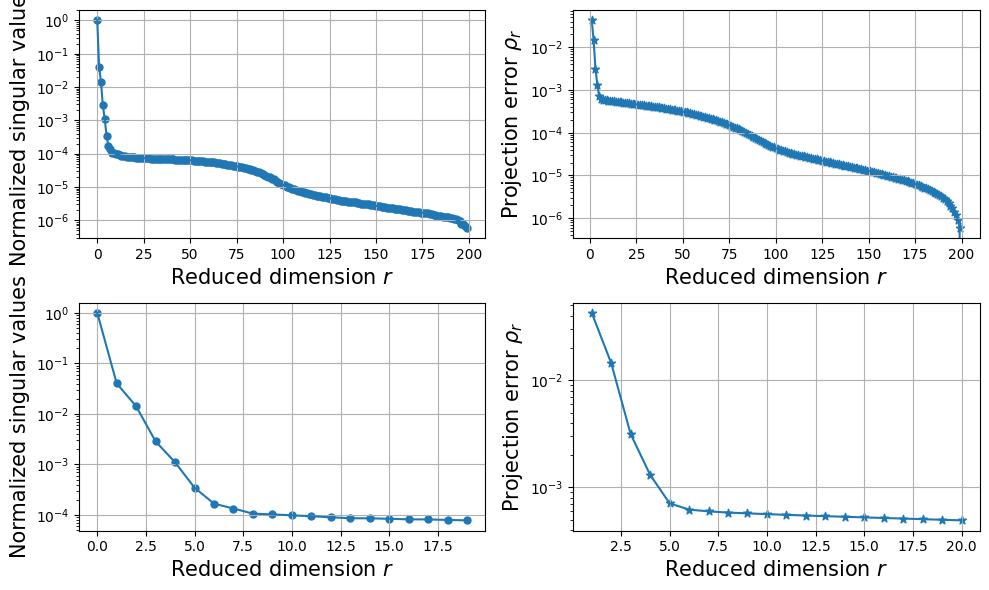

In [9]:
fig = plt.figure(figsize=(10, 6))

# (1,1) Singular values
ax1 = plt.subplot(2, 2, 1)
ax1.semilogy(normalized_sigma, lw=1.5)
ax1.scatter(range(len(normalized_sigma)), normalized_sigma, s=25)
ax1.set_xlabel(r"Reduced dimension $r$", fontsize=15)
ax1.set_ylabel(r"Normalized singular values", fontsize=15)
ax1.grid(True)

# (1,2) Projection error
ax2 = plt.subplot(2, 2, 2)
ax2.semilogy(r, proj_error, lw=1.5)
ax2.scatter(r, proj_error, marker='*')
ax2.set_xlabel(r"Reduced dimension $r$", fontsize=15)
ax2.set_ylabel(r"Projection error $\rho_r$", fontsize=15)
ax2.grid(True)

# (2,1) Singular values (zoom)
ax3 = plt.subplot(2, 2, 3)
ax3.semilogy(normalized_sigma[:20], lw=1.5)
ax3.scatter(range(len(normalized_sigma[:20])), normalized_sigma[:20], s=25)
ax3.set_xlabel(r"Reduced dimension $r$", fontsize=15)
ax3.set_ylabel(r"Normalized singular values", fontsize=15)
ax3.grid(True)

# (2,2) Projection error (zoom)
ax4 = plt.subplot(2, 2, 4)
ax4.semilogy(r[:20], proj_error[:20], lw=1.5)
ax4.scatter(r[:20], proj_error[:20], marker='*')
ax4.set_xlabel(r"Reduced dimension $r$", fontsize=15)
ax4.set_ylabel(r"Projection error $\rho_r$", fontsize=15)
ax4.grid(True)

plt.tight_layout()
plt.show()


In [10]:
# import time

# # ===============================
# # Stochastic OpInf
# # ===============================

# # max r value
# rmax = 20

# # time step
# h = float(tt[1] - tt[0])

# # dimensions
# _, L, s = Qstate_all.shape
# isbilinear = False

# seed_test = 42

# # FOM expectation (average) over all samples
# EFOM = np.mean(Qstate_all, axis=1)          # shape: (n, s)

# # Testing noise sample numbers
# L_test = L * np.array([1, 10])

# # Initialization
# EROM = [None] * len(L_test)
# CROM = [None] * len(L_test)

# f1ROM = [None] * len(L_test)
# f2ROM = [None] * len(L_test)

# E_error = [None] * len(L_test)
# C_error = [None] * len(L_test)

# f1_error = [None] * len(L_test)
# f2_error = [None] * len(L_test)


# # Test with different number of noise samples
# for j in range(len(L_test)):

#     EROM[j] = [None] * rmax
#     CROM[j] = [None] * rmax

#     f1ROM[j] = np.zeros(rmax)
#     f2ROM[j] = np.zeros(rmax)

#     E_error[j] = np.zeros(rmax)
#     C_error[j] = np.zeros(rmax)

#     f1_error[j] = np.zeros(rmax)
#     f2_error[j] = np.zeros(rmax)

#     start_time = time.time()

#     for ii in range(rmax):
#         print(f"ROM dimension {ii + 1}")

#         np.random.seed(seed_test)

#         # Reduced basis
#         Vr_temp = V[:, :ii + 1]               # shape: (n, r)

#         # Project FOM observations
#         # MATLAB pagemtimes(Vr', Qstate_all)
#         Q_train_temp = np.einsum(
#             'rn,nls->rls', Vr_temp.T, Qstate_all
#         )                                     # shape: (r, L, s)

#         # Mean of reduced states    
#         E_train = np.mean(Q_train_temp, axis=1)   # shape: (r, s)

#         # Covariance of reduced states
#         C_train = stoOpinf.page_cov(Q_train_temp, transpose_pages=True)  # (r, r, s)

#         # Drift OpInf
#         Ehatr, Ahatr, Nhatr = stoOpinf.infer_drift(
#             E_train, h, isbilinear, s
#         )

#         # Diffusion OpInf
#         Mhatr, Khatr = stoOpinf.infer_diffusion(
#             C_train, h, Ahatr, Nhatr
#         )

        
#         # ROM function (Wiener process)
#         # def fhatr(x0, Ls):
#         #     return np.linalg.solve(
#         #         (Ehatr - h * Ahatr),
#         #         x0[:, None] + np.sqrt(h) * Mhatr @ np.random.randn(Mhatr.shape[1], Ls)
#         #     )
#         def fhatr(x0, Ls):
#             """
#             x0: shape (r,) or (r, L)
#             Ls: number of samples
#             """
#             # ensure x0 is 2D: (r, Ls)
#             if x0.ndim == 1:
#                 x0 = x0[:, None]  # shape (r,1)

#             # stochastic increment
#             noise = np.sqrt(h) * Mhatr @ np.random.randn(Mhatr.shape[1], Ls)  # shape (r, Ls)
#             B = x0 + noise  # shape (r, Ls)

#             # Solve linear system
#             X_next = np.linalg.solve(Ehatr - h * Ahatr, B)  # shape (r, Ls)

#             return X_next


#         # ROM initial condition
#         xr0 = Vr_temp.T @ EFOM[:, 0]

#         # ROM simulation
#         Eopinf, Copinf, f1opinf, f2opinf = stoOpinf.compute_model(
#             fhatr, Vr_temp, xr0, s, L, L_test[j]
#         )
        
#         # Reconstruct FOM dimension
#         E_recon = Vr_temp @ Eopinf            # shape: (n, s)

#         EROM[j][ii] = E_recon
#         CROM[j][ii] = Copinf

#         f1ROM[j][ii], f2ROM[j][ii] = f1opinf, f2opinf
        
#         # Errors
#         E_error[j][ii] = (
#             np.linalg.norm(E_train - Eopinf, ord='fro')
#             / np.linalg.norm(E_train, ord='fro')
#         )

#         C_error[j][ii] = (
#             stoOpinf.page_norm(C_train - Copinf)
#             / stoOpinf.page_norm(C_train)
#         )

#     print(f"Elapsed time: {time.time() - start_time:.2f} s")


# # Pack errors
# error = {
#     "E_error": E_error,
#     "C_error": C_error,
# }


In [11]:
# # r values
# r = np.linspace(1, rmax, rmax)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='w')

# # Plot Expectation and Covariance errors for all L_test
# for j, L_val in enumerate(L_test):
#     # Expectation error
#     axes[0].plot(
#         r, error['E_error'][j], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
#     )
#     axes[0].set_yscale('log')
#     axes[0].set_xlabel("Reduced dimension $r$", fontsize=12)
#     axes[0].set_ylabel("$e_E$", fontsize=12)
#     axes[0].set_title("Expectation error")
#     axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)
#     axes[0].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

#     # Covariance error
#     axes[1].plot(
#         r, error['C_error'][j], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
#     )
#     axes[1].set_yscale('log')
#     axes[1].set_xlabel("Reduced dimension $r$", fontsize=12)
#     axes[1].set_ylabel("$e_C$", fontsize=12)
#     axes[1].set_title("Covariance error")
#     axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)
#     axes[1].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

# # Add legend outside the plots
# # axes[0].legend(title="Number of noise samples", fontsize=10)
# axes[1].legend(title="Number of noise samples", fontsize=10)

# plt.tight_layout()
# plt.show()


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

# ===============================
# Stochastic OpInf
# ===============================

rmax = 20
h = float(tt[1] - tt[0])

_, L, s = Qstate_all.shape
isbilinear = False
seed_test = 42

EFOM = np.mean(Qstate_all, axis=1)

L_test = L * np.array([1, 10])

# -------------------------------
# Worker function (ONE task = (j, ii))
# -------------------------------
def run_case(j, ii):

    np.random.seed(seed_test + j * 1000 + ii)

    Vr_temp = V[:, :ii + 1]

    Q_train_temp = np.einsum('rn,nls->rls', Vr_temp.T, Qstate_all)

    E_train = np.mean(Q_train_temp, axis=1)
    C_train = stoOpinf.page_cov(Q_train_temp, transpose_pages=True)

    Ehatr, Ahatr, Nhatr = stoOpinf.infer_drift(
        E_train, h, isbilinear, s
    )

    Mhatr, Khatr = stoOpinf.infer_diffusion(
        C_train, h, Ahatr, Nhatr
    )

    def fhatr(x0, Ls):

        if x0.ndim == 1:
            x0 = x0[:, None]

        noise = np.sqrt(h) * Mhatr @ np.random.randn(Mhatr.shape[1], Ls)
        B = x0 + noise

        return np.linalg.solve(Ehatr - h * Ahatr, B)

    xr0 = Vr_temp.T @ EFOM[:, 0]

    Eopinf, Copinf, *_ = stoOpinf.compute_model(fhatr, Vr_temp, xr0, s, L, L_test[j])

    E_error = np.linalg.norm(E_train - Eopinf, 'fro') / np.linalg.norm(E_train, 'fro')
    C_error = stoOpinf.page_norm(C_train - Copinf) / stoOpinf.page_norm(C_train)

    return j, ii, E_error, C_error


# -------------------------------
# PARALLEL EXECUTION (45 cores)
# -------------------------------

n_jobs = 45

print(f"Starting {n_jobs}-core parallel execution...")

tasks = [
    (j, ii)
    for j in range(len(L_test))
    for ii in range(rmax)
]

results = []

for res in tqdm(
    Parallel(n_jobs=n_jobs, backend="loky", return_as="generator")(
        delayed(run_case)(j, ii)
        for j, ii in tasks
    ),
    total=len(tasks)
):
    results.append(res)

# Save results (errors)
E_error = np.zeros((len(L_test), rmax))
C_error = np.zeros((len(L_test), rmax))

for j, ii, e, c in results:
    E_error[j, ii] = e
    C_error[j, ii] = c

Starting 45-core parallel execution...


  8%|▊         | 3/40 [00:06<01:16,  2.07s/it]

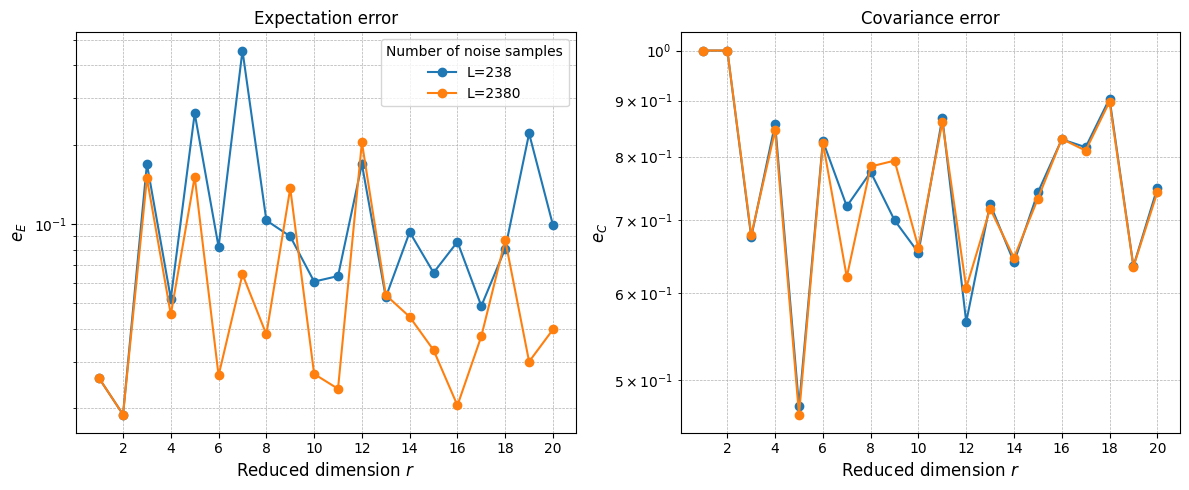

In [13]:
# r values
r = np.linspace(1, rmax, rmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='w')

# Plot Expectation and Covariance errors for all L_test
for j, L_val in enumerate(L_test):
    # Expectation error
    axes[0].plot(
        r, E_error[j,:], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
    )
    axes[0].set_yscale('log')
    axes[0].set_xlabel("Reduced dimension $r$", fontsize=12)
    axes[0].set_ylabel("$e_E$", fontsize=12)
    axes[0].set_title("Expectation error")
    axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[0].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

    # Covariance error
    axes[1].plot(
        r, C_error[j,:], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
    )
    axes[1].set_yscale('log')
    axes[1].set_xlabel("Reduced dimension $r$", fontsize=12)
    axes[1].set_ylabel("$e_C$", fontsize=12)
    axes[1].set_title("Covariance error")
    axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[1].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

axes[0].legend(title="Number of noise samples", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
r_opt = 13
EROM_opt = EROM[1][r_opt-1]
TT, XX = np.meshgrid(tt, x)

fig = plt.figure(figsize=(15, 8), constrained_layout=True)

# 2x3 subplot grid
# Subplot 1: FOM expectation (3D)
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
s1 = ax1.plot_surface(XX, TT, EFOM, cmap=cm.jet, edgecolor='none')
ax1.set_title("FOM expectation")

# Subplot 2: ROM expectation (3D)
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
s2 = ax2.plot_surface(XX, TT, EROM_opt, cmap=cm.jet, edgecolor='none')
ax2.set_title("Stochastic OpInf ROM expectation")

# Match color limits for FOM and ROM
cmin = min(EFOM.min(), EROM_opt.min())
cmax = max(EFOM.max(), EROM_opt.max())
s1.set_clim(cmin, cmax)
s2.set_clim(cmin, cmax)

# Subplot 3: Pointwise relative error (3D)
rel_error = np.abs(EFOM - EROM_opt) / np.abs(EFOM)
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
s3 = ax3.plot_surface(XX, TT, rel_error*100, cmap=cm.hot, edgecolor='none')
ax3.set_title("Pointwise relative error (%)")

# Subplot 4: FOM expectation (top view)
ax4 = fig.add_subplot(2, 3, 4)
s4 = ax4.pcolormesh(TT, XX, EFOM, cmap=cm.jet, shading='auto')
ax4.set_title("FOM expectation (top view)")

# Subplot 5: ROM expectation (top view)
ax5 = fig.add_subplot(2, 3, 5)
s5 = ax5.pcolormesh(TT, XX, EROM_opt, cmap=cm.jet, shading='auto')
ax5.set_title("ROM expectation (top view)")

# Subplot 6: Pointwise relative error (top view)
ax6 = fig.add_subplot(2, 3, 6)
s6 = ax6.pcolormesh(TT, XX, rel_error*100, cmap=cm.hot, shading='auto')
ax6.set_title("Pointwise relative error (%)")

# Overall title
fig.suptitle(f"$r={r_opt}$", fontsize=16, y=1.02)

ax1.view_init(elev=30, azim=-45)
ax2.view_init(elev=30, azim=-45)
ax3.view_init(elev=30, azim=-45)

fig.colorbar(s1, ax=ax1, shrink=0.6, location='right')
fig.colorbar(s2, ax=ax2, shrink=0.6, location='right')
fig.colorbar(s3, ax=ax3, shrink=0.6, location='right')
fig.colorbar(s4, ax=ax4, shrink=0.6, location='right')
fig.colorbar(s5, ax=ax5, shrink=0.6, location='right')
fig.colorbar(s6, ax=ax6, shrink=0.6, location='right')

x_labels_3d = "x [\u03bcm]"
y_labels_3d = "Time [s]"
z_labels_3d = "Surface elevation [\u03bcm]"

x_labels_2d = "Time [s]"
y_labels_2d = "x [\u03bcm]"

for ax in [ax1, ax2]:
    ax.set_xlabel(x_labels_3d)
    ax.set_ylabel(y_labels_3d)
    ax.set_zlabel(z_labels_3d)
    ax.view_init(elev=30, azim=-45)

ax3.set_xlabel(x_labels_3d)
ax3.set_ylabel(y_labels_3d)
ax3.set_zlabel("Relative error (%)")
ax3.view_init(elev=30, azim=-45)

# 2D top-view axes
for ax in [ax4, ax5, ax6]:
    ax.set_xlabel(x_labels_2d)
    ax.set_ylabel(y_labels_2d)

plt.show()


NameError: name 'EROM' is not defined

In [15]:
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
import time

In [16]:
# ----------------------------
# Input signal
# ----------------------------
f_input = 7e6
u_amp = 1
u_train = u_amp * np.cos(2 * np.pi * f_input * tt)

# ----------------------------
# Parameters
# ----------------------------
A_reg = 1
N_reg = 1
B_reg = 1
lambda_reg = np.array([0, 0, 0])

H_reg = np.array([5760])

isbilinear = True
r_all = np.arange(5, 21)

L_test = [L * m for m in [1]]
# L_test = [L * m for m in [1, 10]]

# ----------------------------
# Precompute shared training data ONCE
# ----------------------------
Q_train_all = {
    r: np.einsum('ij,jkl->ikl', V[:, :r].T, Qstate_all)
    for r in r_all
}

E_train_all = {
    r: np.mean(Q_train_all[r], axis=1)
    for r in r_all
}

C_train_all = {
    r: stoOpinf.page_cov(Q_train_all[r], True)
    for r in r_all
}

In [ ]:
from tqdm import tqdm
# Worker function (runs on each core)
def run_case(rr, i_L):

    r = r_all[rr]
    LL = L_test[i_L]

    Vr_temp = V[:, :r]
    xr0 = Vr_temp.T @ EFOM[:, 0]

    E_train = E_train_all[r]
    C_train = C_train_all[r]

    Q_train_temp = Q_train_all[r]

    # OpInf
    Ehatr, Ahatr, Bhatr, Nhatr = stoOpinf.infer_drift_u(
        E_train, u_train, h, isbilinear, lambda_reg
    )

    Mhatr, Khatr = stoOpinf.infer_diffusion_u(
        C_train, u_train, h, Ahatr, Nhatr, H_reg
    )

    sigma = 1.0

    # deterministic RNG per task (IMPORTANT for parallel safety)
    rng = np.random.default_rng(seed_test + rr * 1000 + i_L)

    def fhatr(x0, u, Ls):
        if x0.ndim == 1:    # ensure x0 is 2D: (r, Ls)
            x0 = x0[:, None]  # shape (r,1)

        A = Ehatr - h * Ahatr - h * Nhatr * u
        noise = np.sqrt(h) * (Mhatr @ rng.standard_normal((Mhatr.shape[1], Ls)))
        B = x0 + h * Bhatr * u + noise

        return np.linalg.solve(A, B)

    # ROM simulation
    Eopinf, Copinf = stoOpinf.compute_model_u(
        fhatr, Vr_temp, xr0, u_train, L, LL
    )

    # errors
    E_error = np.linalg.norm(E_train - Eopinf, 'fro') / np.linalg.norm(E_train, 'fro')
    C_error = stoOpinf.page_norm(C_train - Copinf) / stoOpinf.page_norm(C_train)
    
    # Recon
    EROM = Vr_temp @ Eopinf

    return rr, i_L, E_error, C_error, EROM, Copinf


# ----------------------------
# PARALLEL EXECUTION (n CORES)
# ----------------------------
n_jobs = 45

print(f"Starting parallel execution on {n_jobs} cores...")

tasks = [
    (rr, i_L)
    for rr in range(len(r_all))
    for i_L in range(len(L_test))
]

results = []

for res in tqdm(
    Parallel(n_jobs=n_jobs, backend="loky", return_as="generator")(
        delayed(run_case)(rr, i_L)
        for rr, i_L in tasks
    ),
    total=len(tasks)
):
    results.append(res)

# Collect results
E_error = np.zeros((len(r_all), len(L_test)))
C_error = np.zeros((len(r_all), len(L_test)))

EROM_all = [[None for _ in range(len(L_test))] for _ in range(len(r_all))]
Copinf_all = [[None for _ in range(len(L_test))] for _ in range(len(r_all))]

for rr, i_L, e, c, e_rom, c_rom in results:
    E_error[rr, i_L] = e
    C_error[rr, i_L] = c
    
    EROM_all[rr][i_L] = e_rom
    Copinf_all[rr][i_L] = c_rom

Starting parallel execution on 45 cores...


100%|██████████| 16/16 [00:04<00:00,  3.75it/s]


L = 238 -> optimal r = 19, error = 3.754e-02


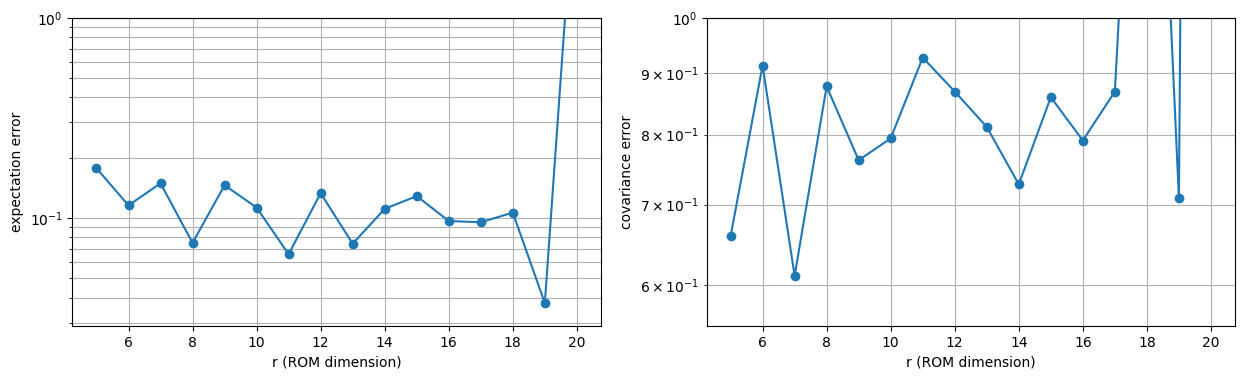

In [ ]:
r_opt_list = []
E_opt_list = []
C_opt_list = []

for i_L, LL in enumerate(L_test):
    idx = np.argmin(E_error[:, i_L])
    r_opt_list.append(r_all[idx])
    E_opt_list.append(E_error[idx, i_L])
    C_opt_list.append(C_error[idx, i_L])

    print(f"L = {LL} -> optimal r = {r_all[idx]}, error = {E_error[idx, i_L]:.3e}")
    
fig, axs = plt.subplots(1, 2, figsize=(15, 4), facecolor='w')

for i_L, LL in enumerate(L_test):
    axs[0].plot(r_all, E_error[:, i_L], '-o', label=f"L={LL}")
    axs[1].plot(r_all, C_error[:, i_L], '-o', label=f"L={LL}")

for i in range(2):
    axs[i].set_yscale('log')
    axs[i].set_xlabel('r (ROM dimension)')
    axs[i].grid(True, which='both')
    axs[i].set_ylim(top = 1)
axs[1].set_ylim([min(C_error)/1.1, 1])
axs[0].set_ylabel('expectation error')
axs[1].set_ylabel('covariance error')
# axs[0].legend()
plt.show()

In [36]:
import pickle

with open("/disk/hyk049/WT_RomFit/0p20/EROM_0p20.pkl", "wb") as f:
    pickle.dump({
        "EFOM": EFOM,
        "EROM_all": EROM_all,
        "Copinf_all": Copinf_all
    }, f)

In [108]:
# # Input signal
# f_input = 7e6
# u_amp = 1
# u_train = u_amp * np.cos(2 * np.pi * f_input * tt)

# # Parameters
# A_reg = 1
# N_reg = 1
# B_reg = 1
# lambda_reg = np.array([0, 0, 0])

# H_reg = np.array([5760])

# isbilinear = True
# r_all = np.arange(5, 21)

# L_test = [L * m for m in [1, 10, 100]]

# # Storage
# E_error = np.zeros((len(r_all), len(L_test)))
# C_error = np.zeros((len(r_all), len(L_test)))

# # Seed
# np.random.seed(seed_test)
    
# for rr, r in enumerate(r_all):

#     print(f"r = {r}")
#     t0 = time.time()

#     Vr_temp = V[:, :r]
#     xr0 = Vr_temp.T @ EFOM[:, 0] 

#     # projection of snapshots
#     Q_train_temp = np.einsum('ij,jkl->ikl', Vr_temp.T, Qstate_all)

#     E_train = np.mean(Q_train_temp, axis=1)
#     C_train = stoOpinf.page_cov(Q_train_temp, True)

    
#     # Drift OpInf (fixed for r)
#     Ehatr, Ahatr, Bhatr, Nhatr = stoOpinf.infer_drift_u(
#         E_train, u_train, h, isbilinear, lambda_reg
#     )
#     # Diffusion OpInf 
#     Mhatr, Khatr = stoOpinf.infer_diffusion_u(
#         C_train, u_train, h, Ahatr, Nhatr, H_reg
#     )

#     sigma = 1

#     # ROM dynamics
#     def fhatr(x0, u, L):
#         # ensure x0 is 2D: (r, Ls)
#         if x0.ndim == 1:
#             x0 = x0[:, None]  # shape (r,1)
            
#         A = Ehatr - h * Ahatr - h * Nhatr * u
#         noise = np.sqrt(h) * Mhatr @ (sigma * np.random.randn(Mhatr.shape[1], L)) # shape (r, L)
#         B = x0 + h * Bhatr * u + noise
#         return np.linalg.solve(A, B)
    
#     for i_L, LL in enumerate(L_test):
#         print(f"L = {LL}")

#         # simulate
#         Eopinf, Copinf = stoOpinf.compute_model_u(
#             fhatr, Vr_temp, xr0, u_train, L, LL
#         )

#         # reconstruction
#         E_recon = Vr_temp @ Eopinf

#         # errors
#         E_error[rr, i_L] = np.linalg.norm(E_train - Eopinf, 'fro') / np.linalg.norm(E_train, 'fro')
#         C_error[rr, i_L] = stoOpinf.page_norm(C_train - Copinf) / stoOpinf.page_norm(C_train)

#         print(f"Elapsed time: {time.time() - t0:.2f} seconds")


r optimal = 19
H_reg optimal = 5760


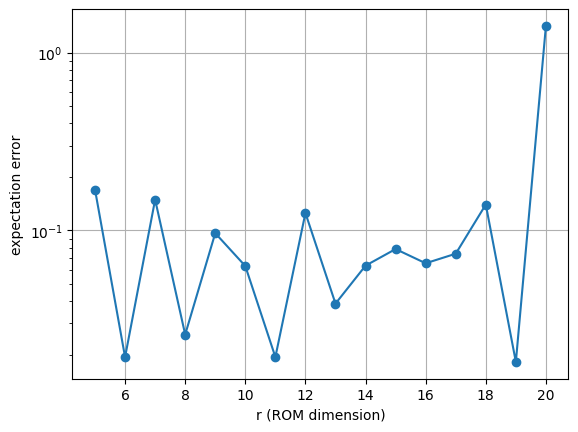

In [132]:
# Find optimal parameters
E_nonzero = E_error[E_error != 0]
min_idx = np.unravel_index(np.argmin(E_error), E_error.shape)

r_min, h_min = min_idx

print(f"r optimal = {r_all[r_min]}")
print(f"H_reg optimal = {H_reg[h_min]}")

# Plot
plt.figure()
plt.plot(r_all, E_error[:, 0], '-o')  # only 1 H_reg column
plt.yscale('log')
plt.xlabel('r (ROM dimension)')
plt.ylabel('expectation error')
plt.grid()
plt.show()

In [80]:
# Parameters
A_reg = np.logspace(-1, 3, 10)
B_reg = np.logspace(0, 8, 10)
N_reg = np.logspace(-1, 5, 10)

B_reg = np.array([0])          # scalar in MATLAB, make array
H_reg_opt = 5760

r_opt = 14

Vr_temp = V[:, :r_opt]         # ROM basis
xr0 = Vr_temp.T @ EFOM[:, 0]   # ROM initial condition

# Project snapshots
Q_train_temp = np.einsum('ij,jkl->ikl', Vr_temp.T, Qstate_all)    # shape (r,L,s)
E_train = np.mean(Q_train_temp, axis=1)                           # shape (r,s)
C_train = stoOpinf.page_cov(Q_train_temp, True)

isbilinear = True

if isbilinear:
    outerLoop = np.arange(len(N_reg))
    ROM_form = 'non-autonomous bilinear ROM'
else:
    outerLoop = np.arange(len(A_reg))
    ROM_form = 'non-autonomous linear ROM'

L_test = [L * m for m in [1, 10]]

Eopinfs = [None] * len(L_test)
EROM = [None] * len(L_test)
CFOM = [None] * len(L_test)
E_error = [None] * len(L_test)
C_error = [None] * len(L_test)

# Main loop
np.random.seed(seed_test)
for iL, LL in enumerate(L_test):
    # Initialization
    Eopinfs[iL] = [None] * len(N_reg)
    EROM[iL] = [None] * len(N_reg)
    CROM[iL] = [None] * len(N_reg)
    E_error[iL] = np.zeros((len(N_reg), len(B_reg)))
    C_error[iL] = np.zeros((len(N_reg), len(B_reg)))

    for ii in outerLoop:
        t0 = time.time()
        print(f"{ii+1}th N_reg")

        Eopinfs[iL][ii] = [None] * len(B_reg)
        EROM[iL][ii] = [None] * len(B_reg)
        CROM[iL][ii] = [None] * len(B_reg)

        for jj, Bval in enumerate(B_reg):

            # regularization vector
            if isbilinear:
                lambda_reg = np.array([0, Bval, N_reg[ii]])
            else:
                lambda_reg = np.array([A_reg[ii], Bval, 0])

            
            # Drift OpInf
            Ehatr, Ahatr, Bhatr, Nhatr = stoOpinf.infer_drift_u(
                E_train, u_train, h, isbilinear, lambda_reg
            )
            # Diffusion OpInf
            Mhatr, Khatr = stoOpinf.infer_diffusion_u(
                C_train, u_train, h, Ahatr, Nhatr, H_reg_opt
            )

            sigma = 1
            
            # ROM dynamics function (Wiener)
            def fhatr(x0, u, L):
                # ensure x0 is 2D: (r, Ls)
                if x0.ndim == 1:
                    x0 = x0[:, None]  # shape (r,1)
                    
                A = Ehatr - h * Ahatr - h * Nhatr * u
                noise = np.sqrt(h) * Mhatr @ (sigma * np.random.randn(Mhatr.shape[1], L)) # shape (r, L)
                B = x0 + h * Bhatr * u + noise
                return np.linalg.solve(A, B)

            # ROM simulation
            Eopinf, Copinf = stoOpinf.compute_model_u(fhatr, Vr_temp, xr0, u_train, L, LL)

            Eopinfs[iL][ii][jj] = Eopinf

            # reconstruct FOM dimension
            E_recon = Vr_temp @ Eopinf
            EROM[iL][ii][jj] = E_recon
            CROM[iL][ii][jj] = Copinf

            # Error computation
            E_error[iL][ii, jj] = np.linalg.norm(E_train - Eopinf, 'fro') / np.linalg.norm(E_train, 'fro')
            C_error[iL][ii, jj] = stoOpinf.page_norm(C_train - Copinf) / stoOpinf.page_norm(C_train)

    print(f"Elapsed time: {time.time() - t0:.2f} seconds")

1th N_reg
2th N_reg
3th N_reg
4th N_reg
5th N_reg
6th N_reg
7th N_reg
8th N_reg
9th N_reg
10th N_reg
Elapsed time: 1.47 seconds
1th N_reg
2th N_reg
3th N_reg
4th N_reg
5th N_reg
6th N_reg
7th N_reg
8th N_reg
9th N_reg
10th N_reg
Elapsed time: 12.51 seconds


In [84]:
E_error[0].shape

(10, 1)

r optimal = 9
H_reg optimal = 0.1


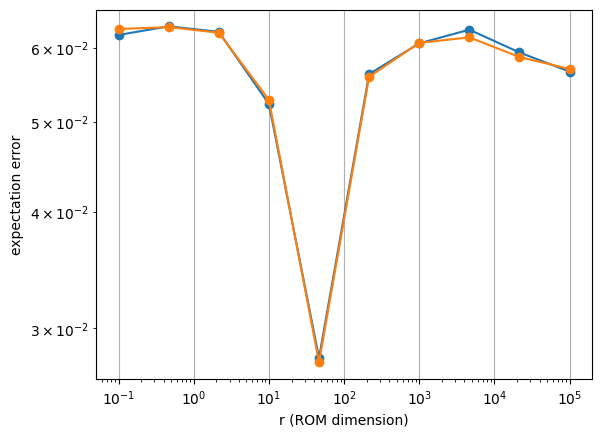

In [87]:
# Find optimal parameters

min_idx = [None] * len(L_test)
for i_L, LL in enumerate(L_test):
    min_idx[i_L] = np.unravel_index(np.argmin(E_error[i_L]), E_error[i_L].shape)

r_min, N_min = min_idx[0]

print(f"r optimal = {r_all[r_min]}")
print(f"H_reg optimal = {N_reg[N_min]}")

# Plot
plt.figure()
plt.plot(N_reg, E_error[0][:], '-o')  # only 1 H_reg column
plt.plot(N_reg, E_error[1][:], '-o')  # only 1 H_reg column
plt.yscale('log')
plt.xscale('log')
plt.xlabel('r (ROM dimension)')
plt.ylabel('expectation error')
plt.grid()
plt.show()

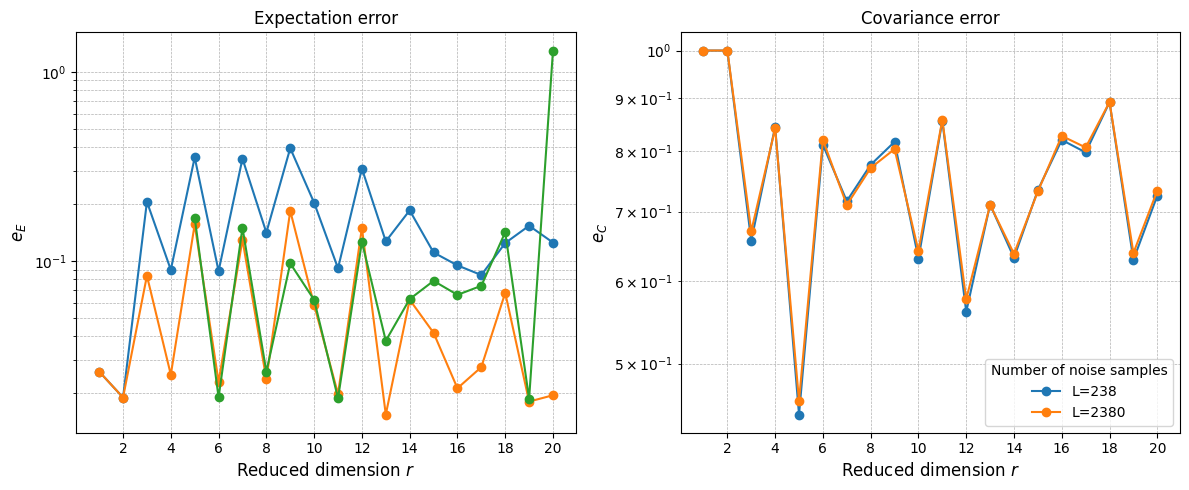

In [65]:
# r values
r = np.linspace(1, rmax, rmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='w')

# Plot Expectation and Covariance errors for all L_test
for j, L_val in enumerate(L_test):
    # Expectation error
    axes[0].plot(
        r, error['E_error'][j], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
    )
    axes[0].set_yscale('log')
    axes[0].set_xlabel("Reduced dimension $r$", fontsize=12)
    axes[0].set_ylabel("$e_E$", fontsize=12)
    axes[0].set_title("Expectation error")
    axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[0].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

    # Covariance error
    axes[1].plot(
        r, error['C_error'][j], '-o', linewidth=1.5, markerfacecolor='auto', label=f"L={L_val}"
    )
    axes[1].set_yscale('log')
    axes[1].set_xlabel("Reduced dimension $r$", fontsize=12)
    axes[1].set_ylabel("$e_C$", fontsize=12)
    axes[1].set_title("Covariance error")
    axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[1].set_xticks(np.arange(2, rmax+1, 2))  # integer ticks

axes[0].plot(r_all, E_error[:, 0], '-o')  # only 1 H_reg column

# Add legend outside the plots
# axes[0].legend(title="Number of noise samples", fontsize=10)
axes[1].legend(title="Number of noise samples", fontsize=10)

plt.tight_layout()
plt.show()
